In [13]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from medmnist import ChestMNIST
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Transform de base (sans augmentation)
transform_base = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# Transform avec augmentation
transform_augmented = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

print("Transforms définis ")
print("\nBase :", transform_base)
print("\nAugmenté :", transform_augmented)

Transforms définis 

Base : Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5], std=[0.5])
)

Augmenté : Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.5], std=[0.5])
)


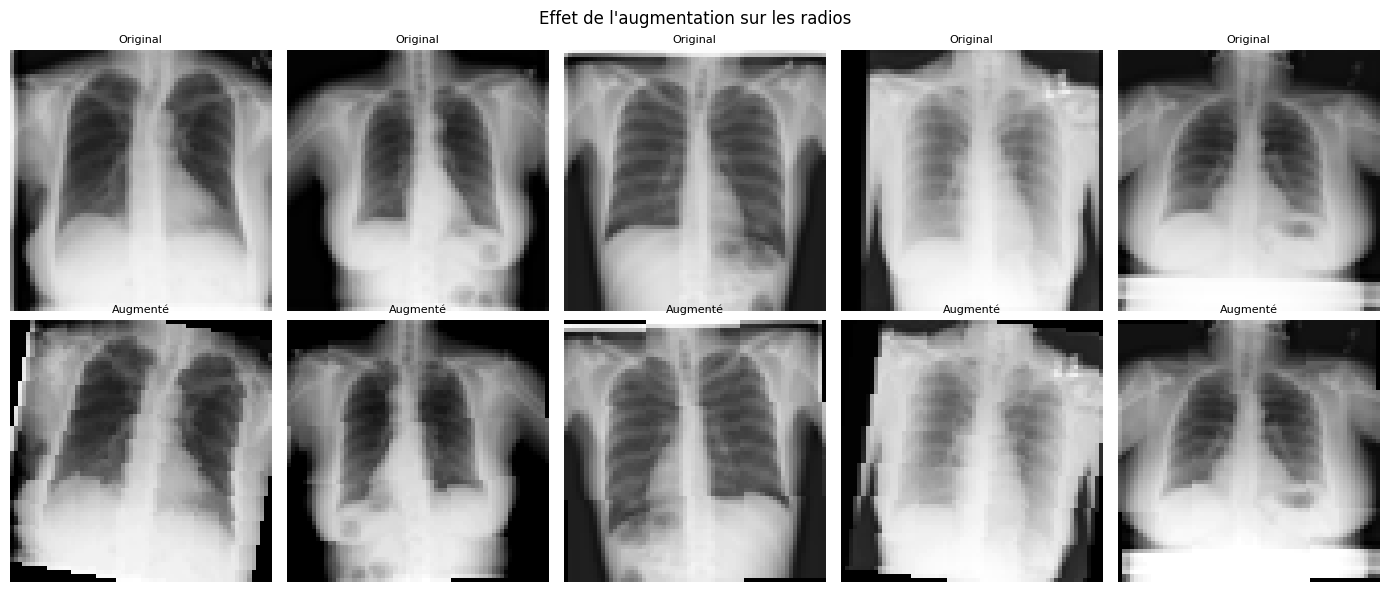

In [15]:
# Charger sans transform pour avoir les images PIL
dataset_raw = ChestMNIST(split='train', download=True, size=64)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

for i in range(5):
    img, _ = dataset_raw[i]
    
    # Ligne 1 : image originale
    axes[0, i].imshow(np.array(img).squeeze(), cmap='gray')
    axes[0, i].set_title('Original', fontsize=8)
    axes[0, i].axis('off')
    
    # Ligne 2 : image augmentée
    img_aug = transform_augmented(img)
    axes[1, i].imshow(img_aug.squeeze(), cmap='gray')
    axes[1, i].set_title('Augmenté', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle("Effet de l'augmentation sur les radios")
plt.tight_layout()
plt.show()

In [16]:
# Train avec augmentation
train_dataset = ChestMNIST(split='train', download=True, size=64, transform=transform_augmented)
val_dataset   = ChestMNIST(split='val',   download=True, size=64, transform=transform_base)
test_dataset  = ChestMNIST(split='test',  download=True, size=64, transform=transform_base)

# Réduire pour CPU
train_dataset = Subset(train_dataset, range(10000))
val_dataset   = Subset(val_dataset,   range(2000))
test_dataset  = Subset(test_dataset,  range(3000))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Train : {len(train_dataset)}")
print(f"Val   : {len(val_dataset)}")
print(f"Test  : {len(test_dataset)}")
print("Data chargée avec augmentation ")

Train : 10000
Val   : 2000
Test  : 3000
Data chargée avec augmentation 


In [17]:
# Calculer les poids par classe pour compenser le déséquilibre
full_train = ChestMNIST(split='train', download=True, size=64)
all_labels = np.array([label for _, label in full_train])

# Poids inversement proportionnels à la fréquence
pos_counts = all_labels.sum(axis=0)
neg_counts = len(all_labels) - pos_counts
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32)

print("Poids par classe (pos_weight) :")
label_names = ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration',
               'mass', 'nodule', 'pneumonia', 'pneumothorax',
               'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']

for name, w in zip(label_names, pos_weight):
    print(f"  {name:<20} : {w:.2f}")

print("\nCes poids seront utilisés dans BCEWithLogitsLoss(pos_weight=pos_weight)")

Poids par classe (pos_weight) :
  atelectasis          : 8.81
  cardiomegaly         : 39.24
  effusion             : 7.47
  infiltration         : 4.64
  mass                 : 18.68
  nodule               : 16.94
  pneumonia            : 79.23
  pneumothorax         : 20.18
  consolidation        : 23.05
  edema                : 45.43
  emphysema            : 42.62
  fibrosis             : 66.76
  pleural              : 33.43
  hernia               : 543.92

Ces poids seront utilisés dans BCEWithLogitsLoss(pos_weight=pos_weight)


In [18]:
from sklearn.model_selection import train_test_split

# Dataset complet sans subset
full_train = ChestMNIST(split='train', download=True, size=64)
all_labels_full = np.array([label for _, label in full_train])

# Indices stratifiés sur atelectasis (classe la plus représentative)
indices = list(range(len(full_train)))
indices_10k, _ = train_test_split(
    indices,
    train_size=10000,
    random_state=42,
    stratify=all_labels_full[:, 0]
)

print(f"Indices stratifiés : {len(indices_10k)} images")

# Vérifier la proportion
labels_10k = all_labels_full[indices_10k]
print("\nProportions dans le subset stratifié :")
label_names = ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration',
               'mass', 'nodule', 'pneumonia', 'pneumothorax',
               'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']
for i, name in enumerate(label_names):
    prop_full = all_labels_full[:, i].mean()
    prop_10k = labels_10k[:, i].mean()
    print(f"  {name:<20} : full={prop_full:.3f} | 10k={prop_10k:.3f}")

# Sauvegarder les indices
torch.save(indices_10k, 'models/indices_10k.pth')
print("\nIndices sauvegardés ✅")

Indices stratifiés : 10000 images

Proportions dans le subset stratifié :
  atelectasis          : full=0.102 | 10k=0.102
  cardiomegaly         : full=0.025 | 10k=0.025
  effusion             : full=0.118 | 10k=0.119
  infiltration         : full=0.177 | 10k=0.177
  mass                 : full=0.051 | 10k=0.052
  nodule               : full=0.056 | 10k=0.053
  pneumonia            : full=0.012 | 10k=0.013
  pneumothorax         : full=0.047 | 10k=0.048
  consolidation        : full=0.042 | 10k=0.042
  edema                : full=0.022 | 10k=0.023
  emphysema            : full=0.023 | 10k=0.024
  fibrosis             : full=0.015 | 10k=0.015
  pleural              : full=0.029 | 10k=0.026
  hernia               : full=0.002 | 10k=0.001

Indices sauvegardés ✅


In [19]:
import os
import pickle

os.makedirs('models', exist_ok=True)

# Sauvegarder les poids
torch.save(pos_weight, 'models/pos_weight.pth')

# Résumé du preprocessing
print("=" * 50)
print("RÉSUMÉ DU PREPROCESSING")
print("=" * 50)
print("Images :")
print("  - Resize : 64x64")
print("  - Normalisation : mean=0.5, std=0.5")
print("  - Augmentation train : HorizontalFlip, Rotation(10°), ColorJitter")
print("  - Augmentation val/test : aucune")
print("\nDéséquilibre :")
print("  - Stratégie : BCEWithLogitsLoss avec pos_weight")
print(f"  - Classe la plus déséquilibrée : hernia (poids={pos_weight[-1]:.1f})")
print(f"  - Classe la plus équilibrée : infiltration (poids={pos_weight[3]:.1f})")
print("\nSplit :")
print("  - Train : 10 000 images")
print("  - Val   : 2 000 images")
print("  - Test  : 3 000 images")
print("\nSeed : torch.manual_seed(42)")
print("=" * 50)
print("Preprocessing terminé ✅")

RÉSUMÉ DU PREPROCESSING
Images :
  - Resize : 64x64
  - Normalisation : mean=0.5, std=0.5
  - Augmentation train : HorizontalFlip, Rotation(10°), ColorJitter
  - Augmentation val/test : aucune

Déséquilibre :
  - Stratégie : BCEWithLogitsLoss avec pos_weight
  - Classe la plus déséquilibrée : hernia (poids=543.9)
  - Classe la plus équilibrée : infiltration (poids=4.6)

Split :
  - Train : 10 000 images
  - Val   : 2 000 images
  - Test  : 3 000 images

Seed : torch.manual_seed(42)
Preprocessing terminé ✅
